In [30]:
import polars as pl
import pyprojroot

ROOT = pyprojroot.here()

In [31]:
data = pl.read_parquet(ROOT/"data"/"processed"/"temporada1_limpio.parquet")
data.columns

['pitch_id',
 'release_speed',
 'batter',
 'pitcher',
 'description',
 'stand',
 'p_throws',
 'pitch_type',
 'balls',
 'strikes',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z',
 'sz_top',
 'sz_bot',
 'swing',
 'sz_mid',
 'strike_zone_size',
 'movement_complexity',
 'platoon_advantage',
 'relative_height',
 'relative_x',
 'is_strike_zone',
 'is_shadow_zone',
 'pitch_location',
 'distance_to_corner',
 'complex_speed',
 'count']

In [32]:
features = [
    "relative_x", "relative_height", "distance_to_corner", "is_strike_zone", "is_shadow_zone",
    "release_speed", "pfx_x", "pfx_z", "strike_zone_size", "count",
    "stand", "p_throws", "pitcher", "pitch_type",
]

X = data.select(features)
y = data.select("swing")

In [33]:
# ================================================================
# SWING PREDICTION — PIPELINE CORREGIDO
# LightGBM + Polars + Cross-Validation + Hyperparameter Tuning
# ================================================================

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GroupKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
import matplotlib.pyplot as plt


# ----------------------------------------------------------------
# 1. CONVERSIÓN POLARS → PANDAS  [BUG FIX x2]
# ----------------------------------------------------------------
cat_cols = ["count", "stand", "p_throws", "pitcher", "pitch_type"]

X = X.with_columns([
    pl.col(c).cast(pl.String).cast(pl.Categorical) for c in cat_cols
])

# BUG FIX #1: sin pyarrow extension arrays — LightGBM requiere pandas estándar
X_pd = X.to_pandas()

# BUG FIX #2: target debe ser Series 1D, no DataFrame
y_pd = y["swing"].to_pandas()

# Cast a category de pandas (no Arrow)
for col in cat_cols:
    X_pd[col] = X_pd[col].astype('category')

print(f"X: {X_pd.shape} | Balance: {y_pd.mean():.3f} (swing rate)")

X: (704721, 14) | Balance: 0.475 (swing rate)


In [36]:
borrar = data["pitch_type"].value_counts().sort("count")

In [37]:
# ----------------------------------------------------------------
# 2. ESTRATEGIA DE CROSS-VALIDATION
# ----------------------------------------------------------------
# En datos de pitcheo hay 3 fuentes de dependencia:
#   (a) Intra-at-bat: pitches del mismo turno al bate están correlacionados
#   (b) Intra-player: el mismo bateador/pitcher en train y test genera leakage
#   (c) Temporal: el modelo no debería ver el futuro
#
# Prioridad de uso:
#   1. GroupKFold por at_bat_id  →  ideal si tenés el ID de turno al bate
#   2. GroupKFold por game_pk    →  si tenés ID de partido
#   3. StratifiedKFold           →  mínimo viable si no tenés grupos

N_SPLITS = 5

# --- Opción A: mínimo viable (siempre disponible) ---
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

In [22]:
# ----------------------------------------------------------------
# 3. ESPACIO DE HIPERPARÁMETROS CORREGIDO
# ----------------------------------------------------------------
# Cambios respecto a la versión original:
#   - 'objective' y 'random_state' removidos del grid (son parámetros fijos)
#   - 'class_weight' removido: 52.5/47.5 no requiere corrección
#   - 'n_estimators' fijo alto → controlado por early stopping en fit final
#   - num_leaves acotado: max_depth=5→≤31, max_depth=6→≤50, max_depth=7→≤63
#   - cat_l2 → reg_lambda (nombre correcto en la API sklearn de LightGBM)
#   - Agregado reg_alpha (L1) para sparsity en features continuas

param_dist = {
    # Estructura del árbol
    'max_depth':          [5, 6, 7],
    'num_leaves':         [20, 31, 50],     # Siempre < 2^max_depth
    'min_child_samples':  [50, 100, 200],   # Mínimo de pitches por hoja

    # Gradiente y estocasticidad
    'learning_rate':      [0.01, 0.05, 0.1],
    'subsample':          [0.7, 0.8, 0.9],
    'colsample_bytree':   [0.7, 0.8, 1.0],

    # Regularización general
    'reg_alpha':          [0.0, 0.1, 0.5],  # L1
    'reg_lambda':         [1.0, 5.0, 10.0], # L2

    # Regularización para categóricas de alta cardinalidad (batter, pitcher)
    'cat_smooth':         [10, 30, 50],      # Prior bayesiano sobre IDs raros
    'min_data_per_group': [50, 100],         # Ignora IDs con muy pocas obs.
}

fixed_params = dict(
    objective='binary',
    n_estimators=150,       # Alto — early stopping define el óptimo real
    importance_type='gain',
    max_cat_to_onehot=4,     # Fuerza histogramas para batter/pitcher
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

In [ ]:
# ----------------------------------------------------------------
# 4. RANDOMIZED SEARCH CON CROSS-VALIDATION (LOGLOSS OPTIMIZADO)
# ----------------------------------------------------------------
search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(**fixed_params), # Usando los params con n_estimators=150
    param_distributions=param_dist,
    n_iter=25,               # O los que hayas configurado
    cv=cv,
    scoring='neg_log_loss',  # <-- CAMBIO CLAVE: Scikit-learn usa logloss negativo
    refit=True,
    n_jobs=-1,
    random_state=42,
    fit_params={"callbacks": [lgb.early_stopping(50)]}
    verbose=1,
    return_train_score=True
)

# Entrenar
search.fit(X_pd, y_pd, categorical_feature=cat_cols)

# Imprimir resultados (le invertimos el signo para leer el LogLoss real)
print(f"\nMejor LogLoss (CV): {-search.best_score_:.4f}") 
print(f"Mejores params: {search.best_params_}")
best_params = search.best_params_

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Mejor LogLoss (CV): 0.1159
Mejores params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 50, 'min_data_per_group': 100, 'min_child_samples': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0, 'cat_smooth': 50}


In [24]:
# ----------------------------------------------------------------
# ANÁLISIS DE RESULTADOS DEL SEARCH
# ----------------------------------------------------------------
results = pd.DataFrame(search.cv_results_)

# Columnas clave — invertir signo para leer LogLoss real (positivo)
results['val_logloss']   = -results['mean_test_score']
results['train_logloss'] = -results['mean_train_score']
results['gap']           =  results['train_logloss'] - results['val_logloss']
# gap negativo  → val mejor que train  (raro, ruido)
# gap ~0        → bien generalizado
# gap positivo  → overfitting

# Ordenar por LogLoss de validación (menor es mejor)
results_sorted = (
    results
    .sort_values('val_logloss')
    [['rank_test_score', 'val_logloss', 'train_logloss', 'gap', 'params']]
    .reset_index(drop=True)
)

print("=== Top 10 combinaciones por LogLoss de validación ===")
print(results_sorted.head(10).to_string(index=False))

# Confirmar que best_params_ coincide con el rank 1
print(f"\nMejor LogLoss val : {results_sorted['val_logloss'].iloc[0]:.4f}")
print(f"Mejor LogLoss train: {results_sorted['train_logloss'].iloc[0]:.4f}")
print(f"Gap               : {results_sorted['gap'].iloc[0]:.4f}")
print(f"\nbest_params_: {search.best_params_}")

=== Top 10 combinaciones por LogLoss de validación ===
 rank_test_score  val_logloss  train_logloss       gap                                                                                                                                                                                                           params
               1     0.115941       0.105799 -0.010142  {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 50, 'min_data_per_group': 100, 'min_child_samples': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0, 'cat_smooth': 50}
               2     0.120519       0.112020 -0.008499  {'subsample': 0.9, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'num_leaves': 50, 'min_data_per_group': 50, 'min_child_samples': 200, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0, 'cat_smooth': 30}
               3     0.121421       0.116227 -0.005194   {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'num_leaves': 20, 'min_data_per_group': 

In [25]:
# Diagnóstico rápido: correlación de cada feature con el target
for col in features:
    if X_pd[col].dtype.name in ['float64', 'int64']:
        corr = X_pd[col].corr(y_pd)
        print(f"{col:25s}  corr={corr:.4f}")

strike_zone_size           corr=0.2981
release_speed              corr=0.0309
pfx_x                      corr=-0.0076
pfx_z                      corr=0.0270
plate_x                    corr=-0.0215
plate_z                    corr=0.0639
balls                      corr=0.1558
strikes                    corr=0.2243
movement_complexity        corr=-0.0145
relative_height            corr=0.0584
relative_x                 corr=-0.0215
pitch_location             corr=-0.4405
distance_to_corner         corr=0.3663
complex_speed              corr=-0.0077


In [ ]:

# ----------------------------------------------------------------
# 5. EVALUACIÓN COMPLETA — LOOP MANUAL DE CV
# ----------------------------------------------------------------
# Usamos loop manual en lugar de cross_validate() para:
#   (a) pasar categorical_feature a cada fold sin conflictos de sklearn
#   (b) guardar predicciones out-of-fold para análisis posterior (OOF probs)
#   (c) calcular las 3 métricas por fold con control total

def run_cv(X, y, cv, params, fixed, cat_cols):
    metrics = {'auc': [], 'logloss': [], 'brier': []}
    oof_proba = np.zeros(len(y))

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = lgb.LGBMClassifier(**fixed, **params)
        model.fit(
            X_tr, y_tr,
            categorical_feature=cat_cols,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(0)]
        )

        proba = model.predict_proba(X_va)[:, 1]
        oof_proba[va_idx] = proba

        metrics['auc'].append(roc_auc_score(y_va, proba))
        metrics['logloss'].append(log_loss(y_va, proba))
        metrics['brier'].append(brier_score_loss(y_va, proba))

        print(f"  Fold {fold+1} | AUC: {metrics['auc'][-1]:.4f} "
              f"| LogLoss: {metrics['logloss'][-1]:.4f} "
              f"| Brier: {metrics['brier'][-1]:.4f}")

    print(f"\n{'─'*55}")
    for m, vals in metrics.items():
        arr = np.array(vals)
        print(f"  {m.upper():<10} {arr.mean():.4f} ± {arr.std():.4f}")

    return metrics, oof_proba

print("\n=== CV con mejores hiperparámetros ===")
cv_metrics, oof_proba = run_cv(X_pd, y_pd, cv, best_params, fixed_params, cat_cols)


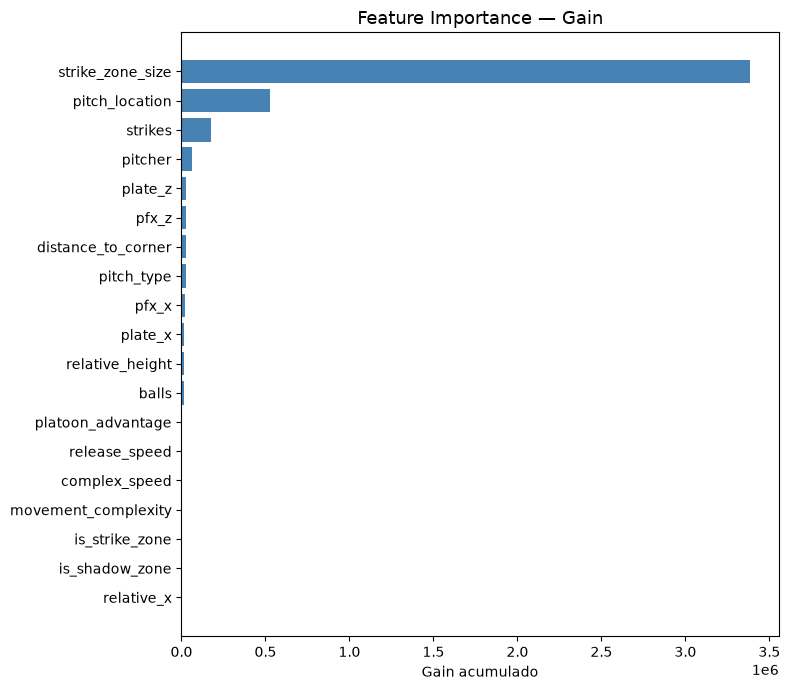

In [26]:

# ----------------------------------------------------------------
# 6. FEATURE IMPORTANCE (GAIN) + VISUALIZACIÓN
# ----------------------------------------------------------------
final_model = search.best_estimator_

importance_df = (
    pd.DataFrame({
        'feature':    X_pd.columns,
        'importance': final_model.feature_importances_
    })
    .sort_values('importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('Feature Importance — Gain', fontsize=13)
ax.set_xlabel('Gain acumulado')
plt.tight_layout()
plt.show()

In [28]:
data.group_by("batter").agg(pl.col("strike_zone_size").n_unique()).sort("strike_zone_size")

batter,strike_zone_size
i64,u32
5279,1
5666,1
6330,1
5172,1
6089,1
…,…
6247,453
6648,467
5083,478
